In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import re

# Load dataset
df = pd.read_csv('annotated_republika.csv')
print("Daftar Kolom:", df.columns) # Untuk memastikan kolom 'title' dan 'label' ada
df.head()

Daftar Kolom: Index(['title', 'label', 'label_score'], dtype='object')


,title,label,label_score
0,Krisis Air Bersih di Lebak Meluas Hingga 16 Ke...,non-clickbait,0
1,Disbudpar Kota Malang Panggil Manajemen Museum...,non-clickbait,0
2,Puskeshaji Layani 471.946 Kunjungan Jamaah Haji,non-clickbait,0
3,Bottas tak Menyerah Incar Gelar Juara F1,non-clickbait,0
4,"Capim KPK, Calon Komisioner yang Wajib Teken K...",non-clickbait,0


In [6]:
def find_punc(text):
    return len(re.findall(r'[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]', str(text)))

def find_uppercase(text):
    return sum(1 for c in str(text) if c.isupper())

def find_lowercase(text):
    return sum(1 for c in str(text) if c.islower())

# Membuat kolom baru di dataframe
df['punc_count'] = df['title'].apply(find_punc)
df['upper_count'] = df['title'].apply(find_uppercase)
df['lower_count'] = df['title'].apply(find_lowercase)

# Membersihkan teks untuk AI
def cleaning(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    return text.lower()

df['cleaned_title'] = df['title'].apply(cleaning)

In [7]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['cleaned_title'])
sequences = tokenizer.texts_to_sequences(df['cleaned_title'])
X_text = pad_sequences(sequences, maxlen=20)

# Mengambil fitur angka
X_punc = df[['punc_count', 'upper_count', 'lower_count']].values

# SOLUSI: Mengubah label teks ke angka 0 dan 1
y = df['label'].map({'non-clickbait': 0, 'clickbait': 1}).values

In [8]:
X_train_title, X_test_title, X_train_punc, X_test_punc, y_train, y_test = train_test_split(
    X_text, X_punc, y, test_size=0.2, random_state=42
)

In [9]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense, concatenate
from tensorflow.keras.models import Model

# Cabang 1: Untuk Judul (LSTM)
lstm_input = Input(shape=(20,))
x1 = Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32)(lstm_input)
x1 = LSTM(32)(x1)
x1 = Dropout(0.5)(x1)

# Cabang 2: Untuk Fitur Angka (MLP)
dense_input = Input(shape=(3,))
x2 = Dense(32, activation='relu')(dense_input)
x2 = Dropout(0.5)(x2)

# Gabungkan
combined = concatenate([x1, x2])
z = Dense(16, activation='relu')(combined)
output = Dense(1, activation='sigmoid')(z)

model = Model(inputs=[lstm_input, dense_input], outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

In [10]:
# 1. Pastikan label menjadi angka (0 dan 1)
y = df['label'].map({'non-clickbait': 0, 'clickbait': 1}).values

# 2. Bagi ulang datanya agar y_train dan y_test ikut terupdate menjadi angka
X_train_title, X_test_title, X_train_punc, X_test_punc, y_train, y_test = train_test_split(
    X_text, X_punc, y, test_size=0.2, random_state=42
)

# 3. Pastikan tipe data y adalah float/int agar tidak ditolak model
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print("Siap! Data label sudah berubah menjadi angka.")

Siap! Data label sudah berubah menjadi angka.


In [11]:
history = model.fit(
    x=[X_train_title, X_train_punc],
    y=y_train,
    epochs=4,
    batch_size=64,
    validation_data=([X_test_title, X_test_punc], y_test)
)

Epoch 1/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - acc: 0.3267 - loss: 2.4485 - val_acc: 0.8800 - val_loss: 0.3863
Epoch 2/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - acc: 0.7217 - loss: 0.8728 - val_acc: 0.8800 - val_loss: 0.6142
Epoch 3/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.7725 - loss: 0.7897 - val_acc: 0.8800 - val_loss: 0.4827
Epoch 4/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.7517 - loss: 0.6663 - val_acc: 0.8800 - val_loss: 0.4225


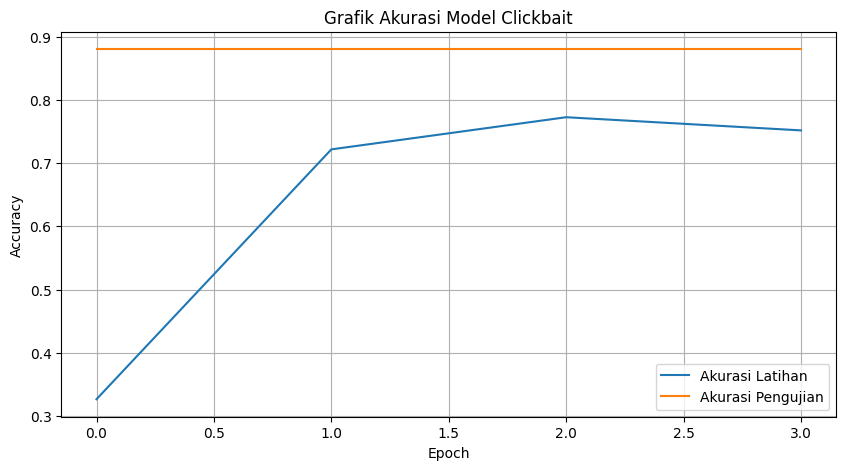

In [12]:
import matplotlib.pyplot as plt

# Membuat grafik akurasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['acc'], label='Akurasi Latihan')
plt.plot(history.history['val_acc'], label='Akurasi Pengujian')
plt.title('Grafik Akurasi Model Clickbait')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Menentukan parameter
max_words = 5000
max_len = 100

# 2. Tokenizing teks judul berita
tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['title'].values)
X = tokenizer.texts_to_sequences(df['title'].values)
X = pad_sequences(X, maxlen=max_len)

# 3. Target label (0 atau 1)
y = df['label'].map({'non-clickbait': 0, 'clickbait': 1}).values

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training Model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.8217 - loss: 0.4940 - val_accuracy: 0.8800 - val_loss: 0.3634
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - accuracy: 0.8358 - loss: 0.4254 - val_accuracy: 0.8800 - val_loss: 0.3501
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8575 - loss: 0.3208 - val_accuracy: 0.8967 - val_loss: 0.2918
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.9575 - loss: 0.1246 - val_accuracy: 0.8900 - val_loss: 0.2978
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.9892 - loss: 0.0484 - val_accuracy: 0.8600 - val_loss: 0.3701


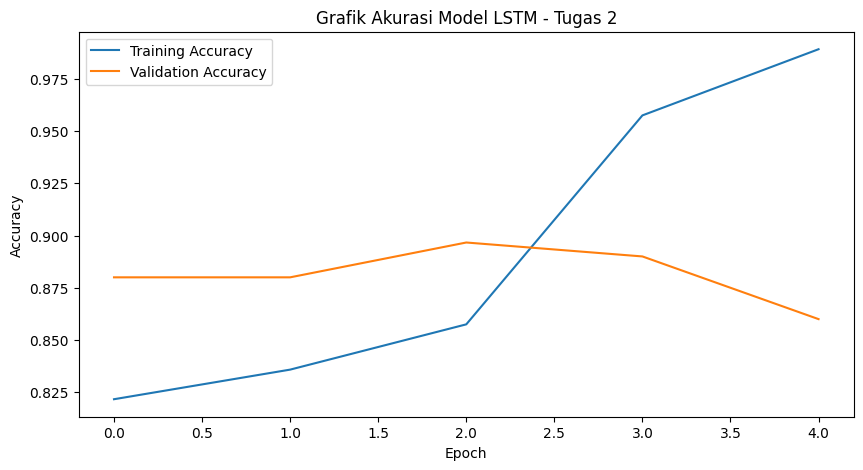

In [15]:
import matplotlib.pyplot as plt

# Grafik Akurasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model LSTM - Tugas 2')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Sedang melatih Model Pembanding (GRU)...
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8158 - loss: 0.5396 - val_accuracy: 0.8800 - val_loss: 0.3787
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.8367 - loss: 0.3792 - val_accuracy: 0.8833 - val_loss: 0.3099
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9167 - loss: 0.1974 - val_accuracy: 0.9100 - val_loss: 0.2868
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9817 - loss: 0.0582 - val_accuracy: 0.8700 - val_loss: 0.3481
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.9958 - loss: 0.0297 - val_accuracy: 0.8700 - val_loss: 0.3904


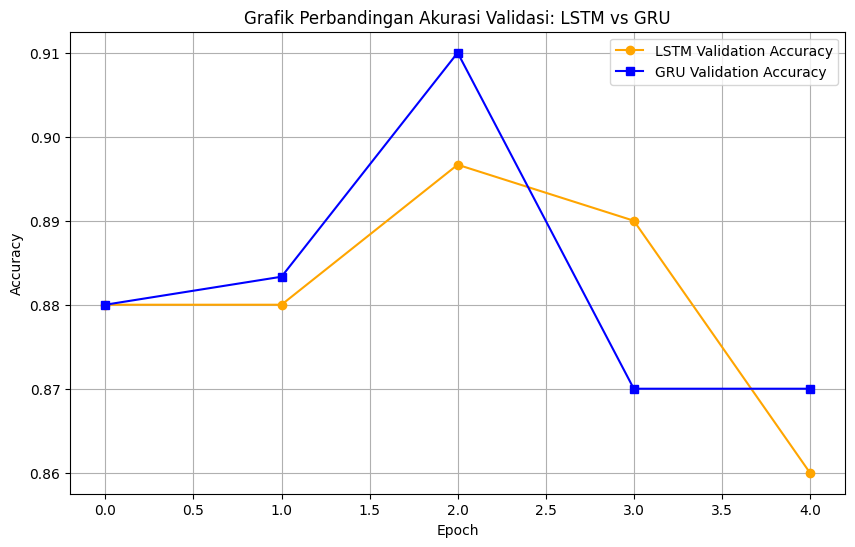

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
import matplotlib.pyplot as plt

# =========================================================
# 1. MEMBUAT MODEL PEMBANDING (GRU)
# =========================================================
print("Sedang melatih Model Pembanding (GRU)...")
model_gru = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Proses Training Model GRU (Samakan 5 Epoch dengan LSTM Anda)
history_gru = model_gru.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# =========================================================
# 2. MEMBUAT GRAFIK PERBANDINGAN GABUNGAN (LSTM VS GRU)
# =========================================================
plt.figure(figsize=(10, 6))

# Plot dari model LSTM sebelumnya (jika variabel 'history' masih aktif di memori)
if 'history' in globals():
    plt.plot(history.history['val_accuracy'], label='LSTM Validation Accuracy', color='orange', marker='o')

# Plot dari model GRU baru
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation Accuracy', color='blue', marker='s')

plt.title('Grafik Perbandingan Akurasi Validasi: LSTM vs GRU')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()